<a href="https://colab.research.google.com/github/joelrvas/pucp-ia-chatbot-work-01/blob/feature%2Fmelqui/Tarea_NLU_with_Bert_no_outputs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BERT

## Requerimientos

In [1]:
!pip install transformers==4.48.3

## Corpus

**Adapted from:** https://github.com/PolyAI-LDN/task-specific-datasets/tree/master/banking_data

In [2]:
! mkdir data

mkdir: cannot create directory ‘data’: File exists


In [3]:
! wget https://raw.githubusercontent.com/PolyAI-LDN/task-specific-datasets/refs/heads/master/banking_data/categories.json -O data/categories.json
! wget https://raw.githubusercontent.com/PolyAI-LDN/task-specific-datasets/refs/heads/master/banking_data/test.csv -O data/test.csv
! wget https://raw.githubusercontent.com/PolyAI-LDN/task-specific-datasets/refs/heads/master/banking_data/train.csv -O data/train.csv

--2025-03-18 01:28:20--  https://raw.githubusercontent.com/PolyAI-LDN/task-specific-datasets/refs/heads/master/banking_data/categories.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2036 (2.0K) [text/plain]
Saving to: ‘data/categories.json’

data/categories.jso 100%[===================>]   1.99K  --.-KB/s    in 0s      

2025-03-18 01:28:21 (37.2 MB/s) - ‘data/categories.json’ saved [2036/2036]

--2025-03-18 01:28:21--  https://raw.githubusercontent.com/PolyAI-LDN/task-specific-datasets/refs/heads/master/banking_data/test.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP 

## Procesando el corpus

In [4]:
import pandas as pd

dataframe_train = pd.read_csv("data/train.csv")

In [5]:
dataframe_train.head()

,text,category
0,I am still waiting on my card?,card_arrival
1,What can I do if my card still hasn't arrived ...,card_arrival
2,I have been waiting over a week. Is the card s...,card_arrival
3,Can I track my card while it is in the process...,card_arrival
4,"How do I know if I will get my card, or if it ...",card_arrival


In [6]:
dataframe_test = pd.read_csv("data/test.csv")

In [7]:
dataframe_test.head()

,text,category
0,How do I locate my card?,card_arrival
1,"I still have not received my new card, I order...",card_arrival
2,I ordered a card but it has not arrived. Help ...,card_arrival
3,Is there a way to know when my card will arrive?,card_arrival
4,My card has not arrived yet.,card_arrival


In [8]:
dataframe_categories = pd.read_json("data/categories.json")

In [9]:
dataframe_categories.columns = ["Categories"]

In [10]:
dataframe_categories.head()

,Categories
0,card_arrival
1,card_linking
2,exchange_rate
3,card_payment_wrong_exchange_rate
4,extra_charge_on_statement


In [11]:
dataframe_categories["Categories"] = pd.Categorical(dataframe_categories["Categories"])

In [12]:
dataframe_categories.head()

,Categories
0,card_arrival
1,card_linking
2,exchange_rate
3,card_payment_wrong_exchange_rate
4,extra_charge_on_statement


In [13]:
intents_to_number_dictionary = dict((label, index) for index, label in enumerate(dataframe_categories["Categories"].cat.categories))

number_to_intents_dictionary = {value: key for key, value in intents_to_number_dictionary.items()}

In [14]:
print(intents_to_number_dictionary)

print(number_to_intents_dictionary)

{'Refund_not_showing_up': 0, 'activate_my_card': 1, 'age_limit': 2, 'apple_pay_or_google_pay': 3, 'atm_support': 4, 'automatic_top_up': 5, 'balance_not_updated_after_bank_transfer': 6, 'balance_not_updated_after_cheque_or_cash_deposit': 7, 'beneficiary_not_allowed': 8, 'cancel_transfer': 9, 'card_about_to_expire': 10, 'card_acceptance': 11, 'card_arrival': 12, 'card_delivery_estimate': 13, 'card_linking': 14, 'card_not_working': 15, 'card_payment_fee_charged': 16, 'card_payment_not_recognised': 17, 'card_payment_wrong_exchange_rate': 18, 'card_swallowed': 19, 'cash_withdrawal_charge': 20, 'cash_withdrawal_not_recognised': 21, 'change_pin': 22, 'compromised_card': 23, 'contactless_not_working': 24, 'country_support': 25, 'declined_card_payment': 26, 'declined_cash_withdrawal': 27, 'declined_transfer': 28, 'direct_debit_payment_not_recognised': 29, 'disposable_card_limits': 30, 'edit_personal_details': 31, 'exchange_charge': 32, 'exchange_rate': 33, 'exchange_via_app': 34, 'extra_charge_

In [15]:
dataframe_categories["Categories"] = dataframe_categories["Categories"].replace(intents_to_number_dictionary)

<ipython-input-15-2b5ef766ea29>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataframe_categories["Categories"] = dataframe_categories["Categories"].replace(intents_to_number_dictionary)
<ipython-input-15-2b5ef766ea29>:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  dataframe_categories["Categories"] = dataframe_categories["Categories"].replace(intents_to_number_dictionary)


In [16]:
dataframe_categories.head()

,Categories
0,12
1,14
2,33
3,18
4,35


In [17]:
dataframe_categories.count()

,0
Categories,77


In [18]:
dataframe_train["category"] = dataframe_train["category"].replace(intents_to_number_dictionary)

<ipython-input-18-1b1de5d9a422>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataframe_train["category"] = dataframe_train["category"].replace(intents_to_number_dictionary)


In [19]:
dataframe_train.head()

,text,category
0,I am still waiting on my card?,12
1,What can I do if my card still hasn't arrived ...,12
2,I have been waiting over a week. Is the card s...,12
3,Can I track my card while it is in the process...,12
4,"How do I know if I will get my card, or if it ...",12


In [20]:
dataframe_train.count()

,0
text,10003
category,10003


In [21]:
dataframe_test["category"] = dataframe_test["category"].replace(intents_to_number_dictionary)

<ipython-input-21-d863c9cb7c4f>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataframe_test["category"] = dataframe_test["category"].replace(intents_to_number_dictionary)


In [22]:
dataframe_test.head()

,text,category
0,How do I locate my card?,12
1,"I still have not received my new card, I order...",12
2,I ordered a card but it has not arrived. Help ...,12
3,Is there a way to know when my card will arrive?,12
4,My card has not arrived yet.,12


In [23]:
dataframe_test.count()

,0
text,3080
category,3080


In [24]:
train_distribution = dataframe_train["category"].value_counts(normalize=True)
test_distribution = dataframe_test["category"].value_counts(normalize=True)

# Mostrar distribución en porcentaje
print("Distribución en entrenamiento:")
print(train_distribution * 100)

print("\nDistribución en prueba:")
print(test_distribution * 100)

Distribución en entrenamiento:
category
16    1.869439
29    1.819454
7     1.809457
75    1.799460
20    1.769469
        ...   
42    0.819754
19    0.609817
11    0.589823
72    0.409877
24    0.349895
Name: proportion, Length: 77, dtype: float64

Distribución en prueba:
category
12    1.298701
14    1.298701
33    1.298701
18    1.298701
35    1.298701
        ...   
20    1.298701
10    1.298701
3     1.298701
69    1.298701
25    1.298701
Name: proportion, Length: 77, dtype: float64


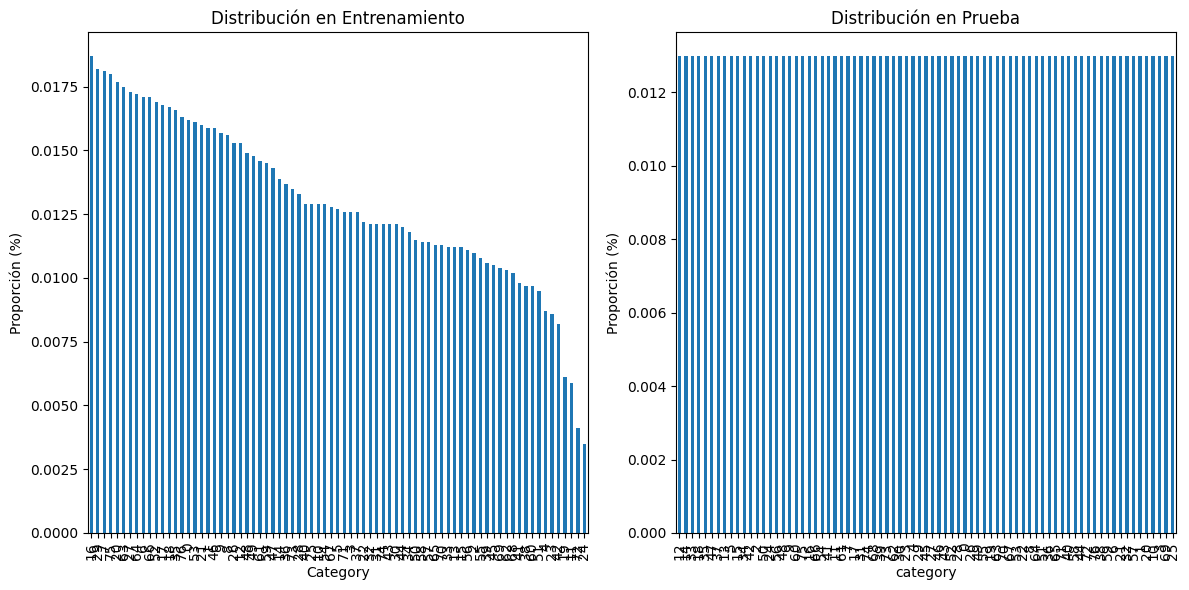

In [25]:
import matplotlib.pyplot as plt

# Graficar la distribución
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
train_distribution.plot(kind="bar", title="Distribución en Entrenamiento")
plt.xlabel("Category")
plt.ylabel("Proporción (%)")

plt.subplot(1, 2, 2)
test_distribution.plot(kind="bar", title="Distribución en Prueba")
plt.xlabel("category")
plt.ylabel("Proporción (%)")

plt.tight_layout()
plt.show()


In [26]:
#Load BERT tokenizer
from transformers import BertTokenizer

#Name of the BERT model to use
model_name = "bert-base-uncased"

#Load BERT tokenizer
tokenizer = BertTokenizer.from_pretrained(pretrained_model_name_or_path=model_name, do_lower_case=True)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


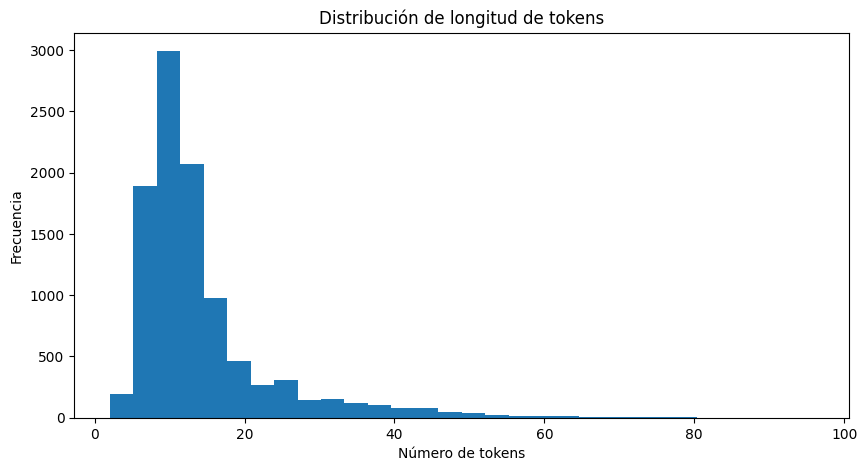

In [27]:
# Tokenizar sin truncar ni rellenar para obtener la longitud real de cada secuencia
token_lens = [len(tokenizer.tokenize(str(text))) for text in dataframe_train["text"]] # Changed 'category' to 'text' and casted text to string using str(text)

# Importar librerías para visualización
import matplotlib.pyplot as plt

# Graficar distribución de longitudes de tokens
plt.figure(figsize=(10,5))
plt.hist(token_lens, bins=30)
plt.xlabel("Número de tokens")
plt.ylabel("Frecuencia")
plt.title("Distribución de longitud de tokens")
plt.show()

In [28]:
import numpy as np

# Calcular percentiles
percentil_90 = np.percentile(token_lens, 90)
percentil_95 = np.percentile(token_lens, 95)

print(f"Percentil 90: {percentil_90}")
print(f"Percentil 95: {percentil_95}")

Percentil 90: 26.0
Percentil 95: 35.0


In [29]:
#Max length of tokens
max_length = 30

In [30]:
#Tokenize train examples
x_train = tokenizer(
                    text=dataframe_train["text"].to_list(),
                    add_special_tokens=True,
                    max_length=max_length,
                    truncation=True,
                    padding="max_length",
                    return_tensors="tf",
                    return_token_type_ids=False,
                    return_attention_mask=True
                   )

In [31]:
#Tokenize test examples
x_test = tokenizer(
                   text=dataframe_test["text"].to_list(),
                   add_special_tokens=True,
                   max_length=max_length,
                   truncation=True,
                   padding="max_length",
                   return_tensors="tf",
                   return_token_type_ids=False,
                   return_attention_mask=True
                  )

## Construcción del modelo

In [32]:
#Load BERT model and configuration
from transformers import TFBertModel, BertConfig

#Load BERT configuration and set output_hidden_states to False
configuration = BertConfig.from_pretrained(model_name)
configuration.output_hidden_states = False

#Load BERT model
transformer_model = TFBertModel.from_pretrained(model_name, config=configuration)
transformer_model.trainable = False

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.seq_relationship.weight', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.seq_relationship.bias', 'cls.predictions.transform.dense.bias', 'cls.predictions.bias']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions w

In [33]:
#Length of input_ids
input_ids_length = x_train["input_ids"].shape[-1]

#Length of attention_mask
attention_mask_length = x_train["attention_mask"].shape[-1]

#Number of intents
intents_number = len(set(dataframe_train["category"]))

In [34]:
#Load Tensorflow Keras (Check https://github.com/huggingface/transformers/issues/29470 for transformers issues with Keras 3)
from tf_keras.layers import Input, Dense
from tf_keras.models import Model
from tf_keras.optimizers import Adam

from tf_keras import backend as K

from tf_keras.utils import plot_model

In [35]:
#Resets all state generated by Keras
K.clear_session()

#Build model inputs
input_ids = Input(shape=(input_ids_length,), name="input_ids", dtype="int32")
attention_mask = Input(shape=(attention_mask_length,), name="attention_mask", dtype="int32")

inputs = {"input_ids": input_ids, "attention_mask": attention_mask}

#Build BERT model as a layer
bert_layer = transformer_model(inputs)
bert_pooling_layer = bert_layer.pooler_output

#Build dense layer
dense = Dense(512, activation="relu", name="dense")(bert_pooling_layer)

#Build model outputs
dense_outputs = Dense(intents_number, activation="softmax", name="outputs")(dense)
outputs = {"outputs": dense_outputs}

#Build Keras model
model = Model(inputs=inputs, outputs=outputs)

In [36]:
#Take a look at the model
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 attention_mask (InputLayer  [(None, 30)]                 0         []                            
 )                                                                                                
                                                                                                  
 input_ids (InputLayer)      [(None, 30)]                 0         []                            
                                                                                                  
 tf_bert_model (TFBertModel  TFBaseModelOutputWithPooli   1094822   ['attention_mask[0][0]',      
 )                           ngAndCrossAttentions(last_   40         'input_ids[0][0]']           
                             hidden_state=(None, 30, 76                                       

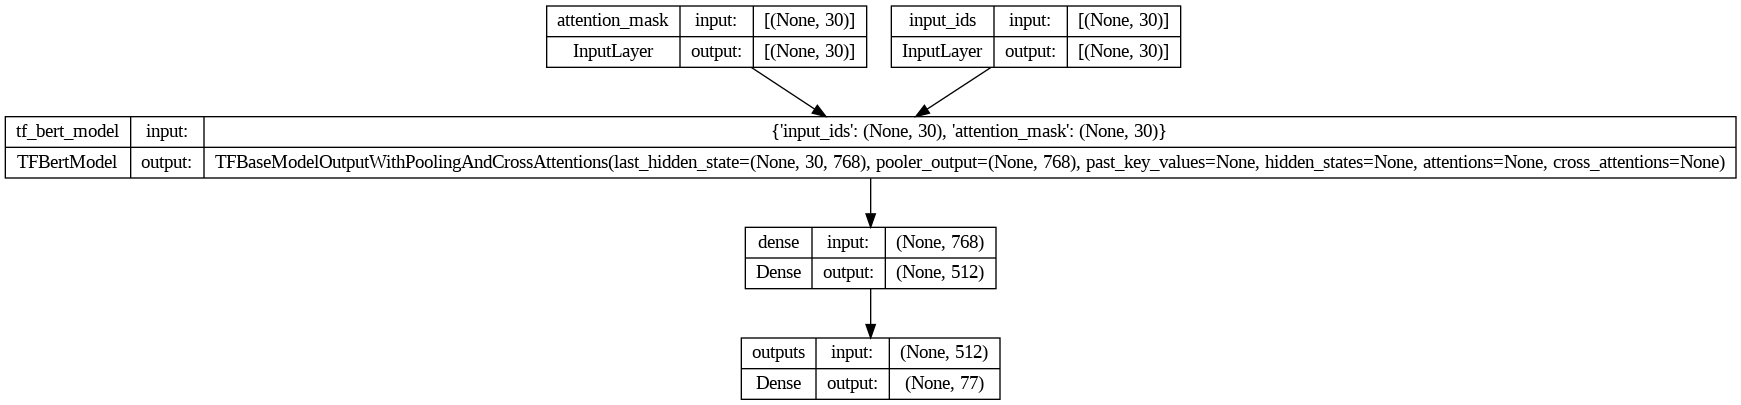

In [37]:
plot_model(model, to_file="model.png", show_shapes=True)

In [38]:
#Build model optimizer
optimizer = Adam(learning_rate=5e-05)

#Compiling the model
model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

## Entrenamiento del modelo

In [39]:
y_train = dataframe_train["category"].to_numpy()

y_test = dataframe_test["category"].to_numpy()

In [40]:
batch_size = 32
epochs = 100

x_train_for_model = {"input_ids": x_train["input_ids"], "attention_mask": x_train["attention_mask"]}
y_train_for_model = {"outputs": y_train}

x_test_for_model = {"input_ids": x_test["input_ids"], "attention_mask": x_test["attention_mask"]}
y_test_for_model = {"outputs": y_test}

In [41]:
from tf_keras.callbacks import ModelCheckpoint

checkpoint_path = "model-{epoch:03d}-{val_accuracy:.4f}.weights.h5"

monitor = "val_accuracy"

mode = "max"

model_checkpoint = ModelCheckpoint(checkpoint_path, monitor=monitor, verbose=1, save_best_only=True, save_weights_only=True, mode=mode)

In [42]:
#Fit the model
#history = model.fit(x=x_train_for_model, y=y_train_for_model, batch_size=batch_size, epochs=epochs, validation_data=(x_test_for_model, y_test_for_model), callbacks=[model_checkpoint])

In [43]:
#Fit more the model
#history = model.fit(x=x_train_for_model, y=y_train_for_model, batch_size=batch_size, epochs=epochs+100, validation_data=(x_test_for_model, y_test_for_model), callbacks=[model_checkpoint], initial_epoch=100)

## Prueba del modelo

In [44]:
import numpy as np

### Máximo accuracy

In [45]:
model.load_weights("model-200-0.6636.weights.h5")

/usr/local/lib/python3.11/dist-packages/transformers/generation/tf_utils.py:465: UserWarning: `seed_generator` is deprecated and will be removed in a future version.
  warnings.warn("`seed_generator` is deprecated and will be removed in a future version.", UserWarning)


In [46]:
prediction = model.predict([x_test["input_ids"][0:1], x_test["attention_mask"][0:1]])

prediction = np.argmax(prediction["outputs"], axis=-1)[0]

prediction = number_to_intents_dictionary[prediction]

prediction

1/1 [==============================] - 5s 5s/step


'lost_or_stolen_phone'

In [47]:
number_to_intents_dictionary[y_test[0]]

'card_arrival'

In [48]:
evaluation = model.evaluate(x=x_test_for_model, y=y_test_for_model)

97/97 [==============================] - 13s 73ms/step - loss: 1.2739 - accuracy: 0.6636


In [49]:
predictions = model.predict([x_test["input_ids"], x_test["attention_mask"]])

97/97 [==============================] - 7s 67ms/step


In [51]:
from sklearn.metrics import classification_report

target_names = list(intents_to_number_dictionary.keys())

print(classification_report(y_test_for_model["outputs"], predictions["outputs"].argmax(axis=-1), target_names=target_names, zero_division=np.nan))

                                                  precision    recall  f1-score   support

                           Refund_not_showing_up        nan      0.00      0.00        40
                                activate_my_card        nan      0.00      0.00        40
                                       age_limit        nan      0.00      0.00        40
                         apple_pay_or_google_pay        nan      0.00      0.00        40
                                     atm_support        nan      0.00      0.00        40
                                automatic_top_up        nan      0.00      0.00        40
         balance_not_updated_after_bank_transfer        nan      0.00      0.00        40
balance_not_updated_after_cheque_or_cash_deposit        nan      0.00      0.00        40
                         beneficiary_not_allowed        nan      0.00      0.00        40
                                 cancel_transfer        nan      0.00      0.00        40
         

## Probando con nuevas variaciones linguisticas creadas por ChatGPT

In [54]:
dataframe_variations = pd.read_csv("data/variations_linguisticas.csv")

In [55]:
dataframe_variations.head(10)

,text,category
0,How can I track my card?,card_arrival
1,Where exactly is my card?,card_arrival
2,Is there a way to find my card?,card_arrival
3,How do I check the location of my card?,card_arrival
4,Can you help me find my missing card?,card_arrival
5,How do exchange rates work?,exchange_rate
6,What’s the current exchange rate?,exchange_rate
7,Can you explain how exchange rates are calcula...,exchange_rate
8,How do I check exchange rates?,exchange_rate
9,What factors affect exchange rates?,exchange_rate


In [56]:
dataframe_variations["category"] = dataframe_variations["category"].replace(intents_to_number_dictionary)

<ipython-input-56-4b319d228f46>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataframe_variations["category"] = dataframe_variations["category"].replace(intents_to_number_dictionary)


In [57]:
dataframe_variations.head(10)

,text,category
0,How can I track my card?,12
1,Where exactly is my card?,12
2,Is there a way to find my card?,12
3,How do I check the location of my card?,12
4,Can you help me find my missing card?,12
5,How do exchange rates work?,33
6,What’s the current exchange rate?,33
7,Can you explain how exchange rates are calcula...,33
8,How do I check exchange rates?,33
9,What factors affect exchange rates?,33


In [58]:
dataframe_variations.count()

,0
text,25
category,25


In [59]:
#Tokenize variations examples
x_variations = tokenizer(
                   text=dataframe_variations["text"].to_list(),
                   add_special_tokens=True,
                   max_length=max_length,
                   truncation=True,
                   padding="max_length",
                   return_tensors="tf",
                   return_token_type_ids=False,
                   return_attention_mask=True
                  )

In [60]:
predictions = model.predict([x_variations["input_ids"], x_variations["attention_mask"]])

predictions = np.argmax(predictions["outputs"], axis=-1)

predictions = [number_to_intents_dictionary[pred] for pred in predictions]

for i, intent in enumerate(predictions):
    print(f"Texto {i+1}: {intent}")

1/1 [==============================] - 0s 103ms/step
Texto 1: lost_or_stolen_phone
Texto 2: lost_or_stolen_phone
Texto 3: transaction_charged_twice
Texto 4: lost_or_stolen_phone
Texto 5: exchange_via_app
Texto 6: lost_or_stolen_phone
Texto 7: lost_or_stolen_phone
Texto 8: transaction_charged_twice
Texto 9: lost_or_stolen_phone
Texto 10: lost_or_stolen_phone
Texto 11: transaction_charged_twice
Texto 12: lost_or_stolen_phone
Texto 13: transaction_charged_twice
Texto 14: lost_or_stolen_phone
Texto 15: lost_or_stolen_phone
Texto 16: lost_or_stolen_phone
Texto 17: exchange_via_app
Texto 18: lost_or_stolen_phone
Texto 19: transaction_charged_twice
Texto 20: lost_or_stolen_phone
Texto 21: transaction_charged_twice
Texto 22: exchange_via_app
Texto 23: lost_or_stolen_phone
Texto 24: lost_or_stolen_phone
Texto 25: lost_or_stolen_phone
